# Distribution of active Wildfires across Australian States/Territories during the last 30 days

#### The goal of this project/notebook is to visualise active wildfires in Australia from the last month. To see how their distribution changed over the 30 days, an animated heatmap is created. Furthermore, to analyse how the amount of wildfires differ between states and territories, a spatial analysis is conducted. The total wildfire numbers over the month are added to the map with a marker cluster layer.

**The notebook is divided into the following sections:**
- Import necessary Libraries/Packages
- Access Data
- Clean and Rearrange Data
- Combine Data via Spatial Join
- Spatial Analysis: Count Fires per State/Territory
- Prepare Data for Heatmap
- Visualise Data with interactive Folium Map


## Import necessary Libraries/Packages
In order to use this notebook, the following libraries need to be imported:

In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import time
from io import StringIO
from datetime import datetime, timedelta
import os #???
import folium
from folium.plugins import HeatMapWithTime
from folium.plugins import MarkerCluster
import numpy as np

# Then set the working directory?
print(os.getcwd())
os.chdir("/Users/silviazemp/Desktop/Uni/FS26/Python/project")
print(os.getcwd())


/Users/silviazemp/Desktop/Uni/FS26/Python/project
/Users/silviazemp/Desktop/Uni/FS26/Python/project


## Access Data
### Access Wildfire Data via API
Active wildfire data is accessed via an API from the NASA's FIRMS Service. By that, a CSV file with near real-time (NRT) data (meaning the time between capturing and processing the data is maximum a few hours) is loaded into the notebook. That way, each time this code cell is executed, the most recent available data is used. For this project means that the DataFrame contains the data of the last month, starting from today and reaching back 30 days.

For this project, the data of NASA's VIIRS sensor (Visible Infrared Imaging Radiometer Suite) is used. This sensor is onboard multiple of NASA's satellites, in particular Suomi NPP, NOAA-20 or NOAA-21. The satellites are all polar orbiting, but they differ by around 1 hour from each other in the timing of crossing the equator. As this timing is not relevant for this project, any of these satellite's data could be used, but Suomi NPP was chosen in this case. 
VIIRS offers a high spatial resolution of 375 m x 375 m pixels, which allows for highly accurate wildfire mapping, including small fires. The data provided is point data, marking the centre of the fire pixel.

In [ ]:
# In order to make use of FIRMS API, a map key, that can be generated from their Website, is needed.
MAP_KEY = '4899a992545cbeb46f9fd0b6a025ef17'

# Set bounding box coordinates for Australia
bbox = '112,-44,154,-9'

# Set end date = today, to get most recent data
end_date = datetime.today()

# Set start date = 30 days ago, to get the last month of data
start_date = end_date - timedelta(days=30)

# Make an empty list of DataFrames (DFs) to fill it with multiple temporary DataFrames from the loop
dfs = []

# Start with oldest data
current_date = start_date

# As FIRMS does not let you load more than 5 days per API request, 
# a loop with multiple requests is needed, each for 5 days of data
while current_date < end_date:

    # Set a range of days that should be loaded per request, in this case the maximum of 5 days
    day_range = 5 

    # Change the date to string format, as API URL cannot contain a datetime format
    date_str = current_date.strftime("%Y-%m-%d") 

    # Build the API URL:
    api_url = (f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
    f"{MAP_KEY}/VIIRS_SNPP_NRT/{bbox}/{day_range}/{date_str}")
    
    # See which day range is currently loading while running the cell
    print(f"Loading: {date_str}")

    # Access the API URL with the request module
    response = requests.get(api_url)

    # If the request is successful (Status Code 200)...
    if response.status_code == 200:
        
        # ...load the response data into a temporary DataFrame...
        # (Note: request.get returns the response from the API URL as a plain text string, not a CSV.
        # StringIO converts the string into a csv-like file format)
        df_temp = pd.read_csv(StringIO(response.text))

        # ...and add this temporary DataFrame to the list of DataFrames created earlier
        dfs.append(df_temp)

    # If the request fails, print an error message
    else:
        print(f"Error {response.status_code}")

    # Pause for 1 second to avoid rate limiting
    time.sleep(1)

    # Move forward by 5 days to load the next 5 days
    current_date += timedelta(days=5)

# Combine all DataFrames from the list into one Dataframe with the concat function (stacks DataFrames)
# (Note: ignore_index makes pandas renumber the index column in the joined file, 
# so that indexes from individual DataFrames are not just added up (->duplicates!))
df_fires = pd.concat(dfs, ignore_index=True)

# Remove duplicates, if any
df_fires = df_fires.drop_duplicates()

# Have a first glimpse at the data
display(df_fires.head(5))
display(df_fires.shape)


Loading: 2026-04-20
Loading: 2026-04-25
Loading: 2026-04-30
Loading: 2026-05-05
Loading: 2026-05-10
Loading: 2026-05-15


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,-29.44152,152.59395,334.11,0.67,0.74,2026-04-20,241,N,VIIRS,n,2.0NRT,292.35,4.25,D
1,-29.44131,152.59901,327.12,0.67,0.74,2026-04-20,241,N,VIIRS,n,2.0NRT,292.65,10.83,D
2,-29.43447,152.59543,328.94,0.67,0.74,2026-04-20,241,N,VIIRS,n,2.0NRT,289.79,4.25,D
3,-29.43667,152.59438,343.37,0.67,0.74,2026-04-20,243,N,VIIRS,n,2.0NRT,291.52,6.72,D
4,-29.43645,152.59914,334.08,0.67,0.74,2026-04-20,243,N,VIIRS,n,2.0NRT,291.97,6.72,D


(78131, 14)

### Load a Boundary GeoPackage File of States/Territories
In order to conduct a spatial analysis, i.e. to see how the amount of wildfire data points differ among the states and territories of Australia, a GeoPackage with polygons of the state/territory boundaries is required.
Here a boundary file from the Australian Bureau of Statistics is used, that has been downloaded to the project folder. 

Source: Australian Bureau of Statistics. (Jul2021-Jun2026). Digital boundary files. ABS. https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs-edition-3/jul2021-jun2026/access-and-downloads/digital-boundary-files.

In [7]:
# Load the GeoPackage of Australian states and territories
# The GeoPackage includes multiple layers of geometries, 
# but for this project only the layer with states and territories (STE) is needed.
gdf_states = gpd.read_file(
    "data/raw/ASGS_2021_Main_Structure_GDA2020.gpkg", layer="STE_2021_AUST_GDA2020")

# Have a glimpse at the data
display(gdf_states.head(5))

# Check which CRS the file contains
print(gdf_states.crs) 

,STATE_CODE_2021,STATE_NAME_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry
0,1,New South Wales,0,No change,AUS,Australia,8.007977e+05,http://linked.data.gov.au/dataset/asgsed3/STE/1,"MULTIPOLYGON (((159.0623 -31.50886, 159.06244 ..."
1,2,Victoria,0,No change,AUS,Australia,2.274962e+05,http://linked.data.gov.au/dataset/asgsed3/STE/2,"MULTIPOLYGON (((146.29286 -39.15778, 146.29275..."
2,3,Queensland,0,No change,AUS,Australia,1.730171e+06,http://linked.data.gov.au/dataset/asgsed3/STE/3,"MULTIPOLYGON (((142.5314 -10.68301, 142.53232 ..."
3,4,South Australia,0,No change,AUS,Australia,9.842314e+05,http://linked.data.gov.au/dataset/asgsed3/STE/4,"MULTIPOLYGON (((140.66025 -38.06256, 140.66046..."
4,5,Western Australia,0,No change,AUS,Australia,2.526632e+06,http://linked.data.gov.au/dataset/asgsed3/STE/5,"MULTIPOLYGON (((117.86953 -35.19108, 117.86945..."


EPSG:7844


In [8]:
# As the WGS84 projection is required for folium maps (that will be used later in the notebook), 
# the CRS needs to be changed to the according EPSG 4326
gdf_states = gdf_states.to_crs(epsg=4326)

# Check again
print(gdf_states.crs) 

EPSG:4326


## Clean and Rearrange Data
### Add a Datetime Column with active Time to the Fire DataFrame
For the animated map, datetime column with an active time format is needed. So far, the Fire DataFrame contains one column with the date of the captured fire point (acq_date) and one column with the time (acq_time). acq_date is a string in the format YYYY-MM_DD, while acq_time is an integer in Greenwich Mean Time (e.g. 603 meaning 6:03). So first, acq_time needs to be converted to string too (with astype(str)), then be filled up to 4 numbers with zeros, so that all times have the same length (with str.zfill(4), e.g. 603 -> 0603), and finally be saved in the format '%Y-%m-%d %H%M'.
After that, both columns can be combined into one column and set to an active datetime format with pandas function to_datetime.

In [9]:
# Convert the acq_time column and combine the acq_date and acq_time column into one column as described above
df_fires['acq_datetime'] = pd.to_datetime(df_fires['acq_date'] + ' ' + df_fires['acq_time'].astype(str).str.zfill(4), format='%Y-%m-%d %H%M')
df_fires.head()

# Check the value range of the new column and confirm our DataFrame contains one month of data
print (f'Australia GMT value range: {df_fires['acq_datetime'].min()} to {df_fires['acq_datetime'].max()}')

Australia GMT value range: 2026-04-20 02:41:00 to 2026-05-19 18:21:00


### Convert raw Coordinates of the Fire DataFrame into Geometries (DataFrame -> GeoDataFrame)
To map the data, the DataFrame (DF) needs to be converted into a GeoDataFrame (GDF) with an active geometry column. As the VIIRS data contains the latitude and longitude of the centre of a fire pixel, they can be converted into a point geometry.

In [10]:
# Convert latitude/longitude values into point geometry 
gdf_fires = gpd.GeoDataFrame(
    df_fires, geometry=gpd.points_from_xy(df_fires.longitude, df_fires.latitude))

# See if the geometry column is added
display(gdf_fires.sample(5))

# Check the CRS of the file
print(gdf_fires.crs) 

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,acq_datetime,geometry
46658,-16.98476,136.36623,367.00,0.54,0.68,2026-05-08,349,N,VIIRS,h,2.0NRT,298.32,28.52,D,2026-05-08 03:49:00,POINT (136.36623 -16.98476)
6067,-35.73217,137.20064,347.06,0.54,0.51,2026-04-22,525,N,VIIRS,n,2.0NRT,295.71,8.31,D,2026-04-22 05:25:00,POINT (137.20064 -35.73217)
17128,-40.86407,144.91365,308.64,0.41,0.61,2026-04-24,1427,N,VIIRS,n,2.0NRT,279.57,2.46,N,2026-04-24 14:27:00,POINT (144.91365 -40.86407)
29378,-32.08523,146.95709,298.80,0.50,0.49,2026-04-30,1554,N,VIIRS,n,2.0NRT,285.37,2.22,N,2026-04-30 15:54:00,POINT (146.95709 -32.08523)
27537,-15.89053,125.01895,339.07,0.49,0.40,2026-04-27,538,N,VIIRS,n,2.0NRT,304.82,4.57,D,2026-04-27 05:38:00,POINT (125.01895 -15.89053)


None


In [11]:
# So far there is no CRS...
# Set CRS to EPSG 4326, to match the States GDF
gdf_fires = gdf_fires.set_crs(epsg=4326)

# Check if it worked
print(gdf_fires.crs) 

EPSG:4326


### Clean both GeoDataFrames: Omit unnecessary Columns
As both GeoDataFrames contain a lot of columns that are not needed for this project, they can be omitted. Like that, the data is clearer, and the joined GDF later will not contain an unnecessary large amount of columns.

In [12]:
# First for the fire GDF
gdf_fires_cleaned = gdf_fires.drop(columns=["bright_ti4", "scan", "track", "confidence", "version", "bright_ti5"])
display(gdf_fires_cleaned.head(3))

# Then the same for the States GDF
gdf_states_cleaned = gdf_states.drop(columns=["CHANGE_FLAG_2021", "CHANGE_LABEL_2021", "AREA_ALBERS_SQKM", "ASGS_LOCI_URI_2021"])
display(gdf_states_cleaned.head(3))

,latitude,longitude,acq_date,acq_time,satellite,instrument,frp,daynight,acq_datetime,geometry
0,-29.44152,152.59395,2026-04-20,241,N,VIIRS,4.25,D,2026-04-20 02:41:00,POINT (152.59395 -29.44152)
1,-29.44131,152.59901,2026-04-20,241,N,VIIRS,10.83,D,2026-04-20 02:41:00,POINT (152.59901 -29.44131)
2,-29.43447,152.59543,2026-04-20,241,N,VIIRS,4.25,D,2026-04-20 02:41:00,POINT (152.59543 -29.43447)


,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,geometry
0,1,New South Wales,AUS,Australia,"MULTIPOLYGON (((159.0623 -31.50886, 159.06244 ..."
1,2,Victoria,AUS,Australia,"MULTIPOLYGON (((146.29286 -39.15778, 146.29275..."
2,3,Queensland,AUS,Australia,"MULTIPOLYGON (((142.5314 -10.68301, 142.53232 ..."


## Combine Data via Spatial Join
To analyse how the amount of fire points detected differs among the states and territories, the two GDFs need to be joined. That way, one GDF is created that contains the fires and the state/territory they are located in. To join them based on their geometries, GeoPandas spatial join is used (sjoin). The strict "inner" join does not allow to consider any fires outside of any Australian state or territory. The original bounding box defined above includes some parts of Indonesia and Papua New Guinea, but those are not of interest for this project, so they will be dropped with the "inner" option. The predicate "within" defines that only fires within the polygon are kept, none that are on the edge and intersect the polygon. As the fires are point data, they are either inside or outside a polygon, so the predicate "intersects" would make no sense here.

In [13]:
# Perform the spatial join
gdf_joined = gpd.sjoin(gdf_fires_cleaned, gdf_states_cleaned, how="inner", predicate="within")

# View the joined attribute table
display(gdf_joined.head(3))

,latitude,longitude,acq_date,acq_time,satellite,instrument,frp,daynight,acq_datetime,geometry,index_right,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021
0,-29.44152,152.59395,2026-04-20,241,N,VIIRS,4.25,D,2026-04-20 02:41:00,POINT (152.59395 -29.44152),0,1,New South Wales,AUS,Australia
1,-29.44131,152.59901,2026-04-20,241,N,VIIRS,10.83,D,2026-04-20 02:41:00,POINT (152.59901 -29.44131),0,1,New South Wales,AUS,Australia
2,-29.43447,152.59543,2026-04-20,241,N,VIIRS,4.25,D,2026-04-20 02:41:00,POINT (152.59543 -29.43447),0,1,New South Wales,AUS,Australia


## Spatial Analysis: Count Fires per State/Territory
Now that all data is nicely combined in one GeoDataFrame, it is interesting to analyse how the amount of fire points detected by the satellite differs between the indivual States and Territories of Australia. For this, the amount of fires can be counted, grouped by the states/territories.


STATE_NAME_2021
Australian Capital Territory        7
New South Wales                  6298
Northern Territory              23996
Queensland                       3886
South Australia                   761
Tasmania                         1468
Victoria                         4018
Western Australia               37135
dtype: int64

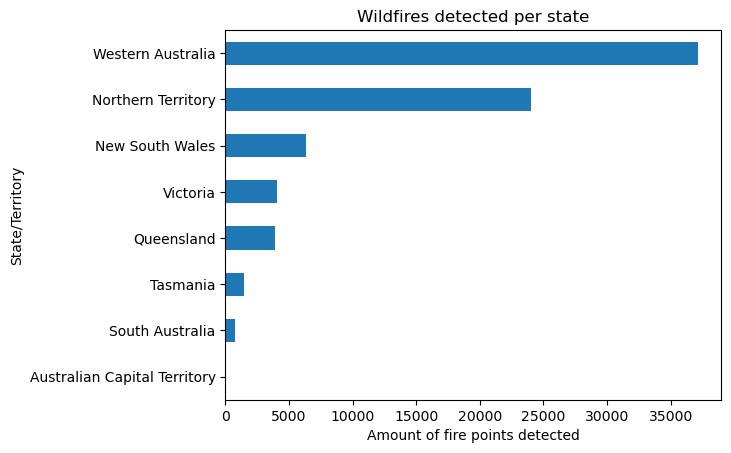

In [14]:
# First the total amount of fire points are grouped by states and counted
fire_count_state = gdf_joined.groupby("STATE_NAME_2021").size()

# Have a look at the numbers
display(fire_count_state)

# In addition, a quick plot helps to visualise those numbers
fire_count_state.sort_values().plot(
    kind="barh")

plt.xlabel("Amount of fire points detected")
plt.ylabel("State/Territory")
plt.title("Wildfires detected per state")
plt.show()

## Temporal Analysis: Count Fires per Day
In addition, it makes sense to also have a quick look at how the numbers evolve over time, so how they differ among the individual dates of the last month.

acq_date
2026-04-20    2146
2026-04-21    3340
2026-04-22    3696
2026-04-23    3714
2026-04-24    5286
2026-04-25    4346
2026-04-26    3060
2026-04-27    3475
2026-04-30     666
2026-05-01    1906
2026-05-02     852
2026-05-03    1451
2026-05-04    2331
2026-05-05    2882
2026-05-06    2878
2026-05-07    4048
2026-05-08    3802
2026-05-09    3617
2026-05-10    2936
2026-05-11    2452
2026-05-12    3201
2026-05-13    3612
2026-05-14    3556
2026-05-15    3927
2026-05-16    2209
2026-05-17     585
2026-05-18     714
2026-05-19     881
dtype: int64

<Axes: xlabel='Date', ylabel='Amount of fire points detected'>

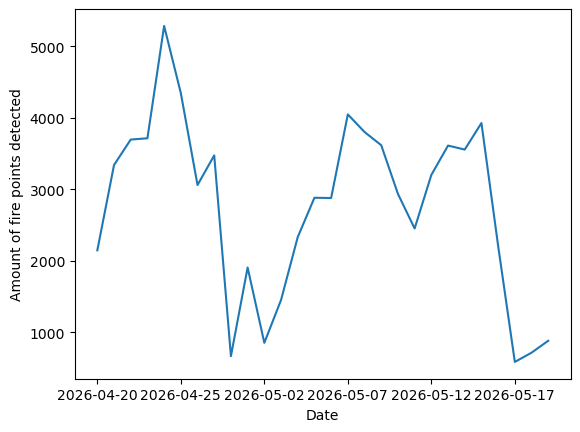

In [15]:
# Now the fires need to be grouped by day and counted
fire_count_date = gdf_joined.groupby("acq_date").size()

# Have a look at the numbers
display(fire_count_date)

# Visualise as well in a quick plot
fire_count_date.plot(xlabel="Date", ylabel="Amount of fire points detected")


## Prepare Data for Heatmap
The animated heatmap in the final visualisation of this project should have a time slider with a daily temporal resolution. Technically, FIRMS provides time data accurate to the minute. However, if data is visualised with a resolution down to the minute or hour, the final animation will look patchy and appears to jump between fires. This tricks the observer into thinking fires randomly extinguished and appeared again in the same spot later. The true reason for this is the satellite behind the data though. Polar orbiting satellites usually have a temporal resolution of a few hours to a few days. In case of Suomi NPP (that hosts the VIIRS Sensor), the full Earth is covered once per day, with each location being captured at least twice (ascending and descending node). This means that the satellite has a revisit time of 12 hours. Inbetween, there are gaps in the data collected, which rises the illusion that there is no fire, even though in reality, the fires are just not captured at this time by the satellite. That is why it does not make sense if the animation is visualised with a higher resolution than daily.

For the heatmap with a daily resolution, a column with an active datetime format, that contains only the date, is required. However, the column created earlier still contains date and time. Therefore the column needs to be reduced to the date. 

In [16]:
# Create a new column "date" with datetime rounded to the day
gdf_joined["date"]= gdf_joined["acq_datetime"].dt.floor("d") 

# Create empty lists to collect...
data = [] # ...heatmap data (coordinates) per day
time_index = [] # ...labels for the time slider

# Group the data by date and for each date...
for time, group in gdf_joined.groupby("date"):
    
    # ...extract all coordinates of fires of this date to a list...
    heat_data = group[["latitude", "longitude"]].values.tolist()
    
    # ...and add these coordinates to the overall list of heatmap data
    data.append(heat_data)

    # Also add the timestamp of this day to the index for the time slider as a string, 
    # but only the date ("%Y-%m-%d"), without the exact time ("%H%M"), as this was rounded
    time_index.append(time.strftime("%Y-%m-%d"))

# Check if it worked
gdf_joined.sample(5)

,latitude,longitude,acq_date,acq_time,satellite,instrument,frp,daynight,acq_datetime,geometry,index_right,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,date
23306,-34.59999,117.42040,2026-04-26,553,N,VIIRS,27.22,D,2026-04-26 05:53:00,POINT (117.4204 -34.59999),4,5,Western Australia,AUS,Australia,2026-04-26
11057,-15.61290,129.30334,2026-04-23,512,N,VIIRS,10.99,D,2026-04-23 05:12:00,POINT (129.30334 -15.6129),6,7,Northern Territory,AUS,Australia,2026-04-23
5239,-18.90204,123.82179,2026-04-21,1700,N,VIIRS,1.65,N,2026-04-21 17:00:00,POINT (123.82179 -18.90204),4,5,Western Australia,AUS,Australia,2026-04-21
70528,-15.89263,127.38237,2026-05-15,459,N,VIIRS,79.04,D,2026-05-15 04:59:00,POINT (127.38237 -15.89263),4,5,Western Australia,AUS,Australia,2026-05-15
20206,-14.37497,130.15591,2026-04-25,434,N,VIIRS,9.83,D,2026-04-25 04:34:00,POINT (130.15591 -14.37497),6,7,Northern Territory,AUS,Australia,2026-04-25


## Visualise Data with interactive Folium Map
The final and most important step of this project: Visualisation! To make the map interactive, a folium map is created with multiple layers that can be toggled on and off. The evolution of wildfires over time is visualised with an animated heatmap. In addition, the fire points are plotted as individual tooltip points and clustered in another layer. The clusters show the number of fires in a certain area and **resembles the spatial analysis from above??**. That way, the Spatial Analysis from above can also be visualised in the final map. 

In [ ]:
# To start, create a basemap with folium for the extent of Australia
aus_map = folium.Map(
    location=[-25.5649, 133.1234], # the coordinates of Australia's centre (25°56′49.3″S, 133°12′34.7″E)
    zoom_start=5, # with a zoom of 5, the map nicely depicts the entire country and some of the sea around
    tiles=None)  # tiles (the look of the basemap) will be added in the next step

# Add the tile layer individually to custom the name of the basemap that will be shown in the layer control
folium.TileLayer(
    tiles="CartoDB Positron", # a neutral basemap to nicely contrast the heatmap and marker clusters
    name="Basemap" # the name that should appear in the layer control
).add_to(aus_map)

# Add the boundary GDF with State/Territory polygons
folium.GeoJson(
    gdf_states_cleaned,
    name="States/Territories",
    tooltip=folium.GeoJsonTooltip(
        fields=["STATE_NAME_2021"], # when scrolling over a state, the name of it should appear
        aliases=["State/Territory:"] 
    ),
    style_function=lambda feature:{
        "fillColor": "lightblue", # color that the polygons should be filled with
        "color": "darkblueb", # colour of the boundary lines
        "weight": 0.5} # thickness of the lines
).add_to(aus_map)

# Add the animated heatmap with the function HeatMapWithTime 
# (Note: HeatMapWithTime is based on Kernel Density Rendering and creates individual heatpoints with a local maximum in the middle (red) for each fire data point, 
# if the fires are close to each other and the radius of their heatpoints overlap, the intensity is added and bigger red areas appear.)
HeatMapWithTime(
    data, # the data list off all fires per day as created earlier
    name="Animated Heatmap", # the name of the layer for the layer control
    index=time_index, # the labels for the timeslider (days) as created earlier
    radius=8, # the radius for the heatpoint created around each fire point (the bigger => the more heatpoints overlap => the more red in the final map)
    auto_play=True, # animation should start playing by itself once map is opened
    max_opacity=0.8, # maximum opacity of 0.8, so that basemap and borders can still slightly be seen under heatpoints
    gradient={  # the color gradient for the heatpoints
        0.2: "blue",
        0.4: "lime",
        0.6: "yellow",
        0.8: "orange",
        1.0: "red"}
).add_to(aus_map)

# Create Marker Cluster Layer with number of fires
# Start with an empty layer
marker_cluster = MarkerCluster(name="Total Wildfires: Clusters").add_to(aus_map)
# Then iterate through the GeoDataFrame
for idx, row in gdf_joined.iterrows():
    lat = row.geometry.y # extract latitude from the geometry column
    lon = row.geometry.x # extract longitude from the geometry column

    # Add a tooltip with the Fire Radiative Power from the frp column as an interesting bonus to appear when hovering over a marker
    tooltip_text = f"Fire Radiative Power: {row['frp']} Megawatts" 

    # Add the markers to the marker cluster layer
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color="orange", icon="fire", prefix="fa"), # make the markers appear as orange fires
        tooltip=tooltip_text # add the defined tooltip text
    ).add_to(marker_cluster)

# Add a layer control to enabe the user to toggle the different layers on and off
folium.LayerControl().add_to(aus_map) 

# Finally, save the map as an html file
aus_map.save("animated_heatmap_with_clusters_month_VIIRS.html")